# 02 · Modelo: clasificación de la clase enzimática por secuencia

Entrada: `data/processed/enzimas_equilibrado.csv`

Pasos:
1. Cargar datos
2. Separar train y test **por organismo** (sin organismos compartidos)
3. Representar cada secuencia con frecuencias de aminoácidos, dipéptidos y tripéptidos
4. Líneas base (clase mayoritaria y regresión logística) y kNN con distancia coseno
5. Elegir `k` por validación cruzada **agrupada por organismo**
6. Evaluar en test: accuracy, F1 macro y matriz de confusión
7. Ver los vecinos más cercanos de una proteína (lo que enseñará la interfaz)
8. Guardar el modelo final con `joblib`
9. Calibrar confianza

In [1]:
import json
import joblib
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import date

from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                                ConfusionMatrixDisplay)
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import Normalizer, StandardScaler

BASE = Path("..") if Path("../data").exists() else Path(".")
DATOS = BASE / "data" / "processed" / "enzimas_equilibrado.csv"
MODELOS = BASE / "models"

SEMILLA = 42
TEST_SIZE = 0.2
K_VALORES = [1, 3, 5, 7, 9, 11, 15, 21, 25]
CV_FOLDS = 5

NOMBRES_CLASE = {
    1: "1 Oxidorreductasas", 2: "2 Transferasas", 3: "3 Hidrolasas", 4: "4 Liasas",
    5: "5 Isomerasas", 6: "6 Ligasas", 7: "7 Translocasas",
}

## 1. Cargar datos

In [2]:
df = pd.read_csv(DATOS)
print(df.shape)
print(df.columns.tolist())
df["clase"].value_counts().sort_index()

(10500, 8)
['Entry', 'Entry Name', 'Protein names', 'Organism', 'Length', 'Sequence', 'EC number', 'clase']


clase
1    1500
2    1500
3    1500
4    1500
5    1500
6    1500
7    1500
Name: count, dtype: int64

## 2. Split train/test por organismo

Si la misma especie estuviera en train y en test, el modelo encontraría proteínas casi idénticas
(mismo organismo, familias repetidas) y la métrica saldría inflada. Separando **por organismo**,
ningún organismo aparece en los dos conjuntos.

In [3]:
grupos = df["Organism"]

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=SEMILLA)
idx_train, idx_test = next(gss.split(df, df["clase"], groups=grupos))

train = df.iloc[idx_train].reset_index(drop=True)
test = df.iloc[idx_test].reset_index(drop=True)

assert set(train["Organism"]).isdisjoint(set(test["Organism"]))

print(f"Train: {len(train)} filas, {train['Organism'].nunique()} organismos")
print(f"Test:  {len(test)} filas, {test['Organism'].nunique()} organismos")

pd.DataFrame({
    "train": train["clase"].value_counts().sort_index(),
    "test": test["clase"].value_counts().sort_index(),
})

Train: 8321 filas, 1513 organismos
Test:  2179 filas, 379 organismos


,train,test
clase,,
1,1201,299
2,1211,289
3,1176,324
4,1194,306
5,1198,302
6,1187,313
7,1154,346


## 3. Representación de las secuencias

Cada secuencia se convierte en un vector de **frecuencias de k-meros** (k=1: aminoácidos, 20 columnas;
k=2: dipéptidos, 400; k=3: tripéptidos, 8000). Se cuenta con `CountVectorizer` a nivel de carácter y se
divide por el total de k-meros de la secuencia (`Normalizer` con norma L1), así la longitud no influye.

Los vectores se guardan como matrices dispersas (sparse), porque los de tripéptidos son casi todo ceros.
Todo va dentro de un `Pipeline` que recibe directamente la secuencia como texto, así el modelo guardado
servirá tal cual en la API.

In [4]:
AMINOACIDOS = "ACDEFGHIKLMNPQRSTVWY"
REPRESENTACIONES = {"aminoácidos": 1, "dipéptidos": 2, "tripéptidos": 3}


def kmeros(k):
    """Todos los k-meros posibles de los 20 aminoácidos, en orden fijo."""
    return ["".join(p) for p in itertools.product(AMINOACIDOS, repeat=k)]


def featurizador(k):
    """Secuencia (texto) -> frecuencias de k-meros."""
    return [
        ("kmeros", CountVectorizer(analyzer="char", ngram_range=(k, k),
                                    lowercase=False, vocabulary=kmeros(k))),
        ("frecuencia", Normalizer(norm="l1")),
    ]


for nombre, k in REPRESENTACIONES.items():
    X_demo = Pipeline(featurizador(k)).fit_transform(train["Sequence"].head(5))
    print(f"{nombre:12s} k={k}: {X_demo.shape[1]} columnas, suma por fila = {X_demo.sum(axis=1).A1.round(3)}")

aminoácidos  k=1: 20 columnas, suma por fila = [1. 1. 1. 1. 1.]
dipéptidos   k=2: 400 columnas, suma por fila = [1. 1. 1. 1. 1.]
tripéptidos  k=3: 8000 columnas, suma por fila = [1. 1. 1. 1. 1.]


## 4. Modelos

- **Clase mayoritaria** (`DummyClassifier`): el suelo mínimo que hay que superar.
- **Regresión logística**: línea base con aprendizaje de verdad.
- **kNN** (`KNeighborsClassifier`, distancia coseno): el modelo del proyecto. `k` se elige con validación
  cruzada agrupada por organismo (`GroupKFold`) sobre el train, para que la selección no se haga con fugas.

In [5]:
X_train_txt = train["Sequence"].values
X_test_txt = test["Sequence"].values
y_train = train["clase"].values
y_test = test["clase"].values
g_train = train["Organism"].values

resultados = []


def evaluar(nombre_modelo, representacion, modelo, extra=None):
    pred = modelo.predict(X_test_txt)
    fila = {
        "modelo": nombre_modelo,
        "representación": representacion,
        "accuracy": accuracy_score(y_test, pred),
        "f1_macro": f1_score(y_test, pred, average="macro"),
    }
    if extra:
        fila.update(extra)
    resultados.append(fila)
    print(f"{nombre_modelo:22s} {representacion:12s} acc={fila['accuracy']:.3f}  F1 macro={fila['f1_macro']:.3f}")

dummy = DummyClassifier(strategy="most_frequent").fit(X_train_txt, y_train)
evaluar("clase mayoritaria", "-", dummy)

clase mayoritaria      -            acc=0.133  F1 macro=0.033


In [6]:
mejores_knn = {}

for nombre, k in REPRESENTACIONES.items():
    logreg = Pipeline(featurizador(k) + [
        ("escala", StandardScaler(with_mean=False)),
        ("clf", LogisticRegression(C=0.1, max_iter=300)),
    ]).fit(X_train_txt, y_train)
    evaluar("regresión logística", nombre, logreg)

    pipe_knn = Pipeline(featurizador(k) + [
        ("knn", KNeighborsClassifier(metric="cosine", algorithm="brute")),
    ])
    busqueda = GridSearchCV(
        pipe_knn,
        param_grid={"knn__n_neighbors": K_VALORES},
        cv=GroupKFold(n_splits=CV_FOLDS),
        scoring="f1_macro",
        n_jobs=-1,
    )
    busqueda.fit(X_train_txt, y_train, groups=g_train)
    mejores_knn[nombre] = busqueda
    evaluar("kNN (coseno)", nombre, busqueda.best_estimator_,
            extra={"k": busqueda.best_params_["knn__n_neighbors"],
                    "f1_cv": busqueda.best_score_})

regresión logística    aminoácidos  acc=0.341  F1 macro=0.325
kNN (coseno)           aminoácidos  acc=0.573  F1 macro=0.561


C:\Users\Motamed\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 300 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=300).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


regresión logística    dipéptidos   acc=0.512  F1 macro=0.499
kNN (coseno)           dipéptidos   acc=0.674  F1 macro=0.665
regresión logística    tripéptidos  acc=0.743  F1 macro=0.739
kNN (coseno)           tripéptidos  acc=0.815  F1 macro=0.811


## 5. Resultados

In [7]:
tabla = pd.DataFrame(resultados)
tabla.round(3)

,modelo,representación,accuracy,f1_macro,k,f1_cv
0,clase mayoritaria,-,0.133,0.033,NaN,NaN
1,regresión logística,aminoácidos,0.341,0.325,NaN,NaN
2,kNN (coseno),aminoácidos,0.573,0.561,1.0,0.522
3,regresión logística,dipéptidos,0.512,0.499,NaN,NaN
4,kNN (coseno),dipéptidos,0.674,0.665,1.0,0.638
5,regresión logística,tripéptidos,0.743,0.739,NaN,NaN
6,kNN (coseno),tripéptidos,0.815,0.811,1.0,0.782


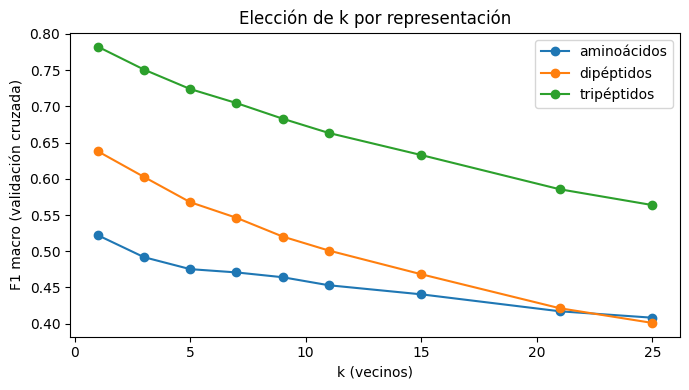

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
for nombre, busqueda in mejores_knn.items():
    ks = busqueda.cv_results_["param_knn__n_neighbors"].data.astype(int)
    ax.plot(ks, busqueda.cv_results_["mean_test_score"], marker="o", label=nombre)
ax.set_xlabel("k (vecinos)")
ax.set_ylabel("F1 macro (validación cruzada)")
ax.set_title("Elección de k por representación")
ax.legend()
plt.tight_layout()
plt.show()

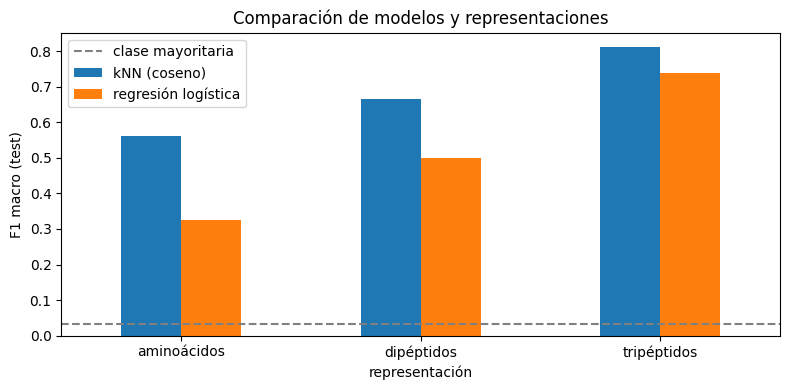

In [9]:
pivote = tabla[tabla["representación"] != "-"].pivot(index="representación", columns="modelo", values="f1_macro")
pivote = pivote.loc[list(REPRESENTACIONES)]
ax = pivote.plot(kind="bar", figsize=(8, 4))
ax.axhline(tabla.loc[tabla["modelo"] == "clase mayoritaria", "f1_macro"].iloc[0],
            color="gray", linestyle="--", label="clase mayoritaria")
ax.set_ylabel("F1 macro (test)")
ax.set_title("Comparación de modelos y representaciones")
ax.tick_params(axis="x", rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Mejor configuración: informe y matriz de confusión

La representación ganadora se elige por el **F1 de validación cruzada** (calculado solo con train),
no por el resultado en test, para no ajustar las decisiones mirando el test.

Representación elegida: tripéptidos  |  k = 1  |  F1 CV = 0.782
                    precision    recall  f1-score   support

1 Oxidorreductasas      0.943     0.666     0.780       299
    2 Transferasas      0.809     0.689     0.744       289
      3 Hidrolasas      0.893     0.667     0.763       324
          4 Liasas      0.836     0.850     0.843       306
      5 Isomerasas      0.845     0.901     0.872       302
         6 Ligasas      0.737     0.939     0.826       313
    7 Translocasas      0.750     0.971     0.846       346

          accuracy                          0.815      2179
         macro avg      0.830     0.812     0.811      2179
      weighted avg      0.829     0.815     0.811      2179



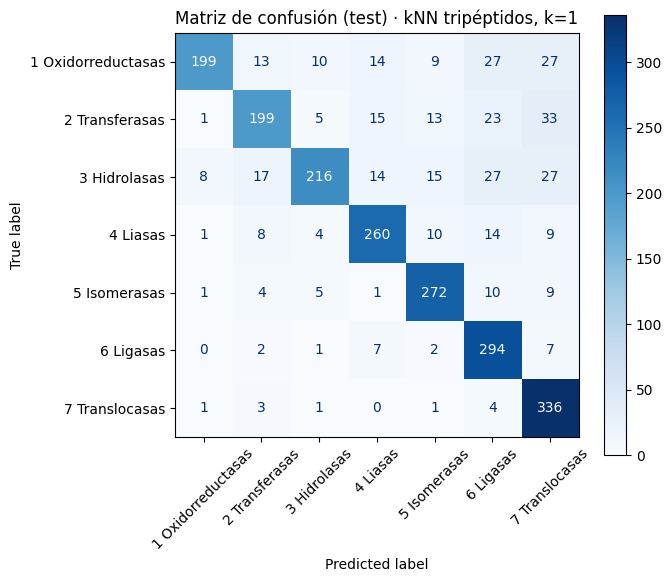

In [10]:
solo_knn = tabla[tabla["modelo"] == "kNN (coseno)"]
mejor_repr = solo_knn.loc[solo_knn["f1_cv"].idxmax(), "representación"]
mejor = mejores_knn[mejor_repr]
k_final = mejor.best_params_["knn__n_neighbors"]
print(f"Representación elegida: {mejor_repr}  |  k = {k_final}  |  F1 CV = {mejor.best_score_:.3f}")

modelo_eval = mejor.best_estimator_
pred = modelo_eval.predict(X_test_txt)
etiquetas = sorted(NOMBRES_CLASE)

print(classification_report(y_test, pred, labels=etiquetas,
                            target_names=[NOMBRES_CLASE[e] for e in etiquetas], digits=3))

fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred, labels=etiquetas,
    display_labels=[NOMBRES_CLASE[e] for e in etiquetas],
    xticks_rotation=45, cmap="Blues", ax=ax,
)
ax.set_title(f"Matriz de confusión (test) · kNN {mejor_repr}, k={k_final}")
plt.tight_layout()
plt.show()

## 7. Vecinos más cercanos de una proteína

Es lo que mostrará la interfaz: la clase predicha, los votos y los 5 vecinos más cercanos con su enlace a UniProt.

In [11]:
def vecinos(modelo, secuencia, referencia, y_ref, n=5):
    """Clase predicha, votos de los k vecinos y los n vecinos más cercanos."""
    feats = modelo[:-1].transform([secuencia])
    knn = modelo.named_steps["knn"]
    dist, idx = knn.kneighbors(feats, n_neighbors=max(n, knn.n_neighbors))
    votos = pd.Series(y_ref[idx[0][:knn.n_neighbors]]).value_counts()
    pred = modelo.predict([secuencia])[0]
    cercanos = referencia.iloc[idx[0][:n]].copy()
    cercanos["distancia_coseno"] = dist[0][:n].round(4)
    return pred, votos, cercanos


col_id = "Entry" if "Entry" in train.columns else "Entry Name"
cols_ver = [c for c in [col_id, "Protein names", "Organism", "clase"] if c in train.columns]

ejemplo = test.iloc[0]
pred, votos, cercanos = vecinos(modelo_eval, ejemplo["Sequence"], train[cols_ver], y_train)
print("Proteína de test:", ejemplo[col_id], "| clase real:", ejemplo["clase"], "| predicha:", pred)
print("Votos de los", k_final, "vecinos:", votos.to_dict())
cercanos

Proteína de test: P80458 | clase real: 1 | predicha: 1
Votos de los 1 vecinos: {1: 1}


,Entry,Protein names,Organism,clase,distancia_coseno
349,Q1QQR2,Malate dehydrogenase (EC 1.1.1.37),Nitrobacter hamburgensis (strain DSM 10229 / N...,1,0.2259
1182,B3E9R5,Malate dehydrogenase (EC 1.1.1.37),Trichlorobacter lovleyi (strain ATCC BAA-1151 ...,1,0.6595
811,Q5FGT9,Malate dehydrogenase (EC 1.1.1.37),Ehrlichia ruminantium (strain Gardel),1,0.7107
425,B9LLP6,Malate dehydrogenase (EC 1.1.1.37),Chloroflexus aurantiacus (strain ATCC 29364 / ...,1,0.7382
908,A1BHN9,Malate dehydrogenase (EC 1.1.1.37),Chlorobium phaeobacteroides (strain DSM 266 / ...,1,0.7384


## 8. Modelo final y guardado

Para la interfaz se reentrena con **todos los datos** (train + test) y la configuración elegida:
cuantas más proteínas de referencia, mejores vecinos. Las métricas del informe corresponden al modelo
entrenado solo con train, que es el que se evaluó de forma honesta.

In [12]:
k_repr = REPRESENTACIONES[mejor_repr]

modelo_final = Pipeline(featurizador(k_repr) + [
    ("knn", KNeighborsClassifier(n_neighbors=k_final, metric="cosine", algorithm="brute")),
]).fit(df["Sequence"].values, df["clase"].values)

MODELOS.mkdir(parents=True, exist_ok=True)
joblib.dump(modelo_final, MODELOS / "modelo_knn.joblib")

cols_ref = [c for c in [col_id, "Entry Name", "Protein names", "Organism", "EC number", "clase"] if c in df.columns]
df[cols_ref].to_csv(MODELOS / "referencia.csv", index=False)

fila_knn = tabla[(tabla["modelo"] == "kNN (coseno)") & (tabla["representación"] == mejor_repr)].iloc[0]
meta = {
    "fecha": str(date.today()),
    "representacion": mejor_repr,
    "k_kmero": k_repr,
    "k_vecinos": int(k_final),
    "f1_macro_cv": round(float(mejor.best_score_), 4),
    "accuracy_test": round(float(fila_knn["accuracy"]), 4),
    "f1_macro_test": round(float(fila_knn["f1_macro"]), 4),
    "clases": NOMBRES_CLASE,
    "n_proteinas_referencia": int(len(df)),
}
(MODELOS / "modelo_knn_meta.json").write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(meta, ensure_ascii=False, indent=2))

recargado = joblib.load(MODELOS / "modelo_knn.joblib")
print("Predicción de prueba:", recargado.predict([df['Sequence'].iloc[0]])[0], "| clase real:", df['clase'].iloc[0])

{
  "fecha": "2026-10-07",
  "representacion": "tripéptidos",
  "k_kmero": 3,
  "k_vecinos": 1,
  "f1_macro_cv": 0.7824,
  "accuracy_test": 0.8151,
  "f1_macro_test": 0.8106,
  "clases": {
    "1": "1 Oxidorreductasas",
    "2": "2 Transferasas",
    "3": "3 Hidrolasas",
    "4": "4 Liasas",
    "5": "5 Isomerasas",
    "6": "6 Ligasas",
    "7": "7 Translocasas"
  },
  "n_proteinas_referencia": 10500
}
Predicción de prueba: 1 | clase real: 1


Test rápido para comprobar si me quedo con k=1 o k=5 (numero de votantes) para determinar el tipo de una proteína

In [13]:
b = mejores_knn["tripéptidos"]
pd.DataFrame({
    "k": b.cv_results_["param_knn__n_neighbors"].data.astype(int),
    "f1_cv": b.cv_results_["mean_test_score"].round(3),
})

,k,f1_cv
0,1,0.782
1,3,0.751
2,5,0.724
3,7,0.704
4,9,0.683
5,11,0.663
6,15,0.633
7,21,0.585
8,25,0.564


## 9. Calibrar confianza
La interfaz muestra "confianza alta, media o baja" según la distancia al vecino más cercano.

In [14]:
pred_test = modelo_eval.predict(X_test_txt)
feats_test = modelo_eval[:-1].transform(X_test_txt)
dist, _ = modelo_eval.named_steps["knn"].kneighbors(feats_test, n_neighbors=1)

res = pd.DataFrame({"dist": dist[:, 0], "acierto": (pred_test == y_test)})
res = res.sort_values("dist").reset_index(drop=True)
res["acierto_acumulado"] = res["acierto"].expanding().mean()


def umbral(objetivo, minimo=50):
    """Mayor distancia hasta la cual el acierto acumulado sigue siendo >= objetivo."""
    ok = res[(res.index >= minimo) & (res["acierto_acumulado"] >= objetivo)]
    return None if ok.empty else round(float(ok["dist"].iloc[-1]), 4)


umbrales = {"alta": umbral(0.90), "media": umbral(0.75)}
print("Umbrales de distancia:", umbrales)

res["tramo"] = pd.qcut(res["dist"], 5)
print(res.groupby("tramo", observed=True)["acierto"].mean().round(3))

meta_ruta = MODELOS / "modelo_knn_meta.json"
meta = json.loads(meta_ruta.read_text(encoding="utf-8"))
meta["umbrales_distancia"] = umbrales
meta_ruta.write_text(json.dumps(meta, ensure_ascii=False, indent=2), encoding="utf-8")

Umbrales de distancia: {'alta': 0.826, 'media': 0.9098}
tramo
(-0.001, 0.251]    1.000
(0.251, 0.563]     0.998
(0.563, 0.713]     0.977
(0.713, 0.804]     0.759
(0.804, 0.91]      0.342
Name: acierto, dtype: float64


476